# 머신 러닝 교과서 3판

# 5장 - 차원 축소를 사용한 데이터 압축

**아래 링크를 통해 이 노트북을 주피터 노트북 뷰어(nbviewer.jupyter.org)로 보거나 구글 코랩(colab.research.google.com)에서 실행할 수 있습니다.**

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://nbviewer.org/github/rickiepark/python-machine-learning-book-3rd-edition/blob/master/ch05/ch05.ipynb"><img src="https://jupyter.org/assets/share.png" width="60" />주피터 노트북 뷰어로 보기</a>
  </td>
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/rickiepark/python-machine-learning-book-3rd-edition/blob/master/ch05/ch05.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />구글 코랩(Colab)에서 실행하기</a>
  </td>
</table>

목차

- 주성분 분석을 통한 비지도 차원 축소
  - 주성분 분석의 주요 단계
  - 주성분 추출 단계
  - 총분산과 설명된 분산
  - 특성 변환
  - 사이킷런의 주성분 분석
- 선형 판별 분석을 통한 지도 방식의 데이터 압축
  - 주성분 분석 vs 선형 판별 분석
  - 선형 판별 분석의 내부 동작 방식
  - 산포 행렬 계산 
  - 새로운 특성 부분 공간을 위해 선형 판별 벡터 선택
  - 새로운 특성 공간으로 샘플 투영
  - 사이킷런의 LDA
- 커널 PCA를 사용하여 비선형 매핑
  - 커널 함수와 커널 트릭
  - 파이썬으로 커널 PCA 구현
    - 예제 1 - 반달 모양 구분하기
    - 예제 2 - 동심원 분리하기
  - 새로운 데이터 포인트 투영
  - 사이킷런의 커널 PCA
- 요약

In [1]:
from IPython.display import Image

# 5.1 주성분 분석을 통한 비지도 차원 축소

## 5.1.1 주성분 분석의 주요 단계

In [2]:
Image(url='https://git.io/JtsvW', width=400)

$\boldsymbol{x}\boldsymbol{W}=\boldsymbol{z}$

## 5.1.2 주성분 추출 단계

In [3]:
import pandas as pd 

df_wine = pd.read_csv('https://archive.ics.uci.edu/ml/'
                      'machine-learning-databases/wine/wine.data',
                      header=None)

# UCI 머신 러닝 저장소에서 Wine 데이터셋을 다운로드할 수 없을 때 
# 다음 주석을 해제하고 로컬 경로에서 데이터셋을 적재하세요:

# df_wine = pd.read_csv('wine.data', header=None)


df_wine.columns = ['Class label', 'Alcohol', 'Malic acid', 'Ash',
                   'Alcalinity of ash', 'Magnesium', 'Total phenols',
                   'Flavanoids', 'Nonflavanoid phenols', 'Proanthocyanins',
                   'Color intensity', 'Hue',
                   'OD280/OD315 of diluted wines', 'Proline']

df_wine.head()

,Class label,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


70%는 훈련 세트로 30%는 테스트 세트로 나눕니다.

In [4]:
from sklearn.model_selection import train_test_split 

X, y = df_wine.iloc[:, 1:].values, df_wine.iloc[:, 0].values 

X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.3,
                     stratify=y,
                     random_state=0)

데이터를 표준화합니다.

In [5]:
from sklearn.preprocessing import StandardScaler 

sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

---

**노트**

`X_test_std = sc.fit_transform(X_test)` 대신에 `X_test_std = sc.transform(X_test)`를 사용했습니다. 이 경우에 테스트 데이터셋의 평균과 표준편차가 훈련 데이터셋과 매우 비슷하기 때문에 큰 차이가 없습니다. 하지만 3장에서 보았듯이 데이터를 변환할 때 훈련 데이터셋에서 학습한 파라미터를 재사용하는 것이 올바른 방법입니다. 테스트 데이터셋은 "새로운 본 적 없는" 데이터를 의미하기 때문입니다.

초기에 `fit_transform(X_test)`를 사용했는데 이것은 모델 훈련에서 얻은 파라미터를 재사용하여 새로운 데이터를 표준화하지 않는 일반적인 실수입니다. 왜 이것이 문제가 되는지 간단한 예를 살펴 보겠습니다.

훈련 데이터셋에 1개의 특성("길이")을 가진 샘플 3개가 들어 있다고 가정해 보죠:

- train_1: 10 cm -> class_2
- train_2: 20 cm -> class_2
- train_3: 30 cm -> class_1

mean: 20, std.: 8.2

표준화를 한 후에 변환된 특성 값은 다음과 같습니다:

- train_std_1: -1.22 -> class_2
- train_std_2: 0 -> class_2
- train_std_3: 1.22 -> class_1

그다음 표준화된 길이가 0.6보다 작은 샘플을 class_2로 분류한다고 가정해 보죠(그 외에는 class_1). 지금까지는 좋습니다. 이제 레이블이 없는 3개의 포인트를 분류한다고 가정해 보죠:

- new_4: 5 cm -> class ?
- new_5: 6 cm -> class ?
- new_6: 7 cm -> class ?

훈련 데이터셋에 있는 표준화되기 전의 "길이" 값과 비교해 보면 직관적으로 이 샘플들은 class_2로 보입니다. 하지만 훈련 데이터셋에서 했던 것처럼 평균과 표준편차를 다시 계산하여 표준화하면 아마도 분류기가 샘플 4번과 5번만 class_2로 분류할 것입니다.

- new_std_4: -1.22 -> class 2
- new_std_5: 0 -> class 2
- new_std_6: 1.22 -> class 1

하지만 훈련 데이터셋의 표준화에 사용했던 파라미터를 사용하면 다음과 같은 값을 얻습니다:

- example5: -1.84 -> class 2
- example6: -1.71 -> class 2
- example7: -1.59 -> class 2

5 cm, 6 cm, 7 cm는 훈련 데이터셋에 있는 어떤 것보다도 작습니다. 따라서 훈련 데이터셋을 표준화한 값보다도 훨씬 작은 값으로 표준화되어야 합니다.

---

공분산 행렬의 고윳값 분해

In [6]:
import numpy as np 
cov_mat = np.cov(X_train_std.T)
eigen_vals, eigen_vecs = np.linalg.eig(cov_mat)

print('\n고윳값 \n%s' % eigen_vals)


고윳값 
[4.84274532 2.41602459 1.54845825 0.96120438 0.84166161 0.6620634
 0.51828472 0.34650377 0.3131368  0.10754642 0.21357215 0.15362835
 0.1808613 ]


**노트**:

위에서 [`numpy.linalg.eig`](http://docs.scipy.org/doc/numpy/reference/generated/numpy.linalg.eig.html) 함수를 사용해 대칭 공분산 행렬을 고윳값과 고유벡터로 분해했습니다.

<pre>>>> eigen_vals, eigen_vecs = np.linalg.eig(cov_mat)</pre>

이것이 잘못된 것은 아니지만 최적은 아닙니다. [에르미트(Hermetian) 행렬](https://en.wikipedia.org/wiki/Hermitian_matrix)를 위해서 설계된 [`numpy.linalg.eigh`](http://docs.scipy.org/doc/numpy/reference/generated/numpy.linalg.eigh.html)를 사용하는 것이 더 좋습니다. 이 함수는 항상 실수 고윳값을 반환합니다. 수치적으로 약간 덜 안정적인 `np.linalg.eig`는 비대칭 정방행렬을 분해할 수 있지만 어떤 경우에 복소수 고윳값을 반환할 수 있습니다.

## 5.1.3 총분산과 설명된 분산

In [7]:
tot = sum(eigen_vals)
var_exp = [(i / tot) for i in sorted(eigen_vals, reverse=True)]
cum_var_exp = np.cumsum(var_exp)

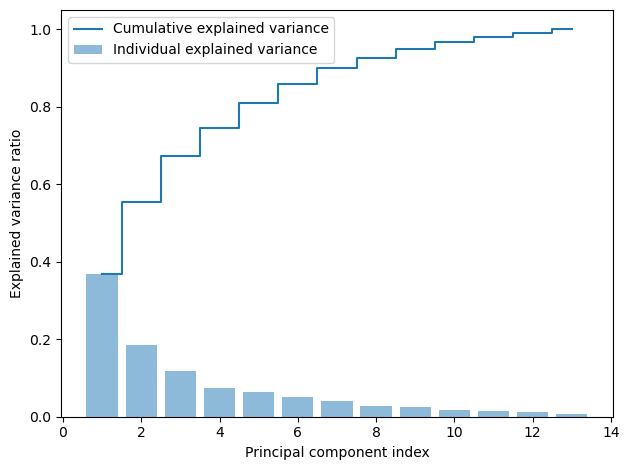

In [8]:
import matplotlib.pyplot as plt


plt.bar(range(1, 14), var_exp, alpha=0.5, align='center',
        label='Individual explained variance')
plt.step(range(1, 14), cum_var_exp, where='mid',
         label='Cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.legend(loc='best')
plt.tight_layout()
# plt.savefig('images/05_02.png', dpi=300)
plt.show()

## 5.1.4 특성 변환

In [9]:
# (고윳값, 고유벡터) 튜플의 리스트를 만듭니다 
eigen_pairs = [(np.abs(eigen_vals[i]), eigen_vecs[:, i])
               for i in range(len(eigen_vals))]

# 높은 값에서 낮은 값으로 (고윳값, 고유벡터) 튜플을 정렬합니다 
eigen_pairs.sort(key=lambda k: k[0], reverse=True)

In [10]:
w = np.hstack((eigen_pairs[0][1][:, np.newaxis],
               eigen_pairs[1][1][:, np.newaxis]))
print('투영 행렬 W:\n', w)

투영 행렬 W:
 [[-0.13724218  0.50303478]
 [ 0.24724326  0.16487119]
 [-0.02545159  0.24456476]
 [ 0.20694508 -0.11352904]
 [-0.15436582  0.28974518]
 [-0.39376952  0.05080104]
 [-0.41735106 -0.02287338]
 [ 0.30572896  0.09048885]
 [-0.30668347  0.00835233]
 [ 0.07554066  0.54977581]
 [-0.32613263 -0.20716433]
 [-0.36861022 -0.24902536]
 [-0.29669651  0.38022942]]


**노트:**

사용하는 Numpy와 LAPACK 버전에 따라 행렬 W의 부호가 바뀔 수 있습니다. 이는 문제가 아닙니다. $v$가 행렬 $\Sigma$의 고유벡터라면 다음을 얻을 수 있습니다.

$$\Sigma v = \lambda v,$$

여기에서 $\lambda$는 고윳값입니다.

$\Sigma \cdot (-v) = -\Sigma v = -\lambda v = \lambda \cdot (-v).$이기 때문에 $-v$도 동일한 고윳값을 가진 고유벡터입니다.

In [11]:
X_train_std[0].dot(w)

array([2.38299011, 0.45458499])

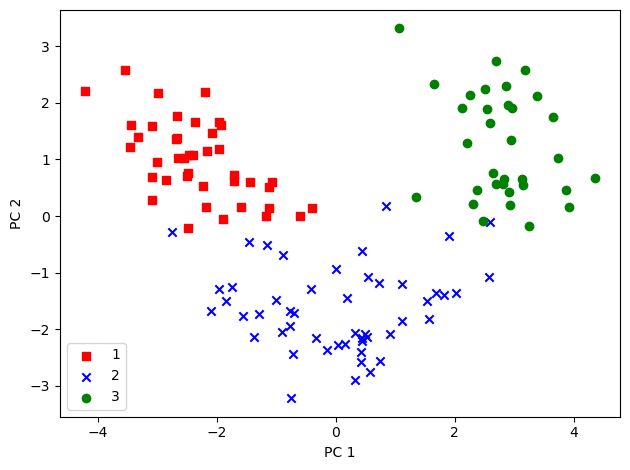

In [12]:
X_train_pca = X_train_std.dot(w)
colors = ['r', 'b', 'g']
markers = ['s', 'x', 'o']

for l, c, m in zip(np.unique(y_train), colors, markers):
    plt.scatter(X_train_pca[y_train == l, 0],
                X_train_pca[y_train == l, 1],
                c=c, label=l, marker=m)

plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='lower left')
plt.tight_layout()
# plt.savefig('images/05_03.png', dpi=300)
plt.show()

## 5.1.5 사이킷런의 주성분 분석

In [13]:
from sklearn.decomposition import PCA

pca = PCA()
X_train_pca = pca.fit_transform(X_train_std)
pca.explained_variance_ratio_

array([0.36951469, 0.18434927, 0.11815159, 0.07334252, 0.06422108,
       0.05051724, 0.03954654, 0.02643918, 0.02389319, 0.01629614,
       0.01380021, 0.01172226, 0.00820609])

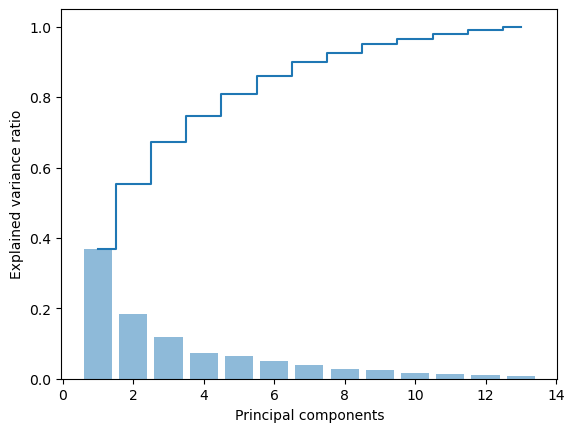

In [14]:
plt.bar(range(1, 14), pca.explained_variance_ratio_, alpha=0.5, align='center')
plt.step(range(1, 14), np.cumsum(pca.explained_variance_ratio_), where='mid')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')

plt.show()

In [15]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_std)
X_test_pca = pca.transform(X_test_std)

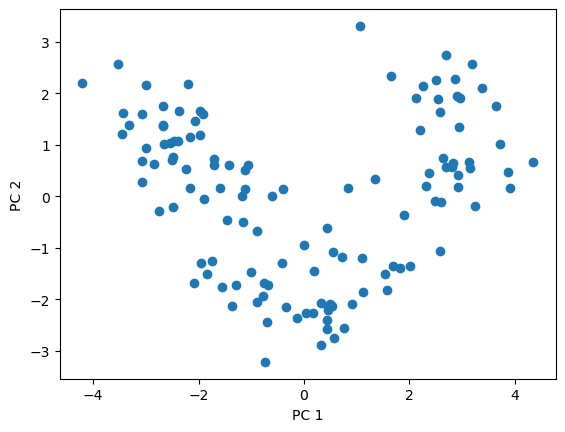

In [16]:
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1])
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.show()

In [18]:
from matplotlib.colors import ListedColormap

def plot_decision_regions(X, y, classifier, resolution=0.02):

    # 마커와 컬러맵을 준비합니다
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # 결정 경계를 그립니다
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.4, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # 클래스별로 샘플을 그립니다
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0],
                    y=X[y == cl, 1],
                    alpha=0.6,
                    color=cmap(idx),
                    edgecolor=None if idx==1 else 'black',
                    marker=markers[idx],
                    label=cl)

처음 두 개의 주성분을 사용하여 로지스틱 회귀 분류기를 훈련합니다.

In [19]:
from sklearn.linear_model import LogisticRegression

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_std)
X_test_pca = pca.transform(X_test_std)

lr = LogisticRegression(random_state=1)
lr = lr.fit(X_train_pca, y_train)

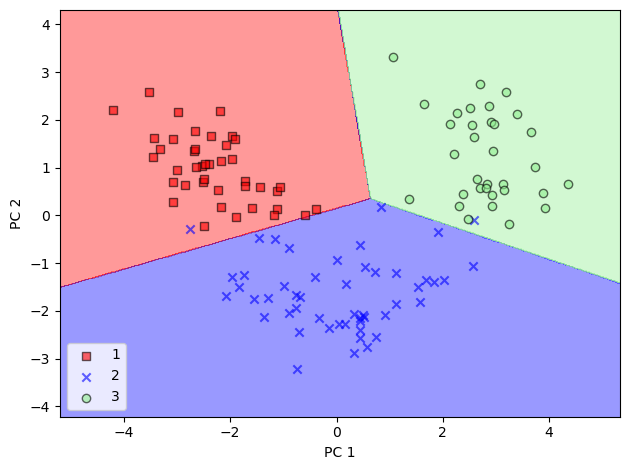

In [20]:
plot_decision_regions(X_train_pca, y_train, classifier=lr)
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='lower left')
plt.tight_layout()
# plt.savefig('images/05_04.png', dpi=300)
plt.show()

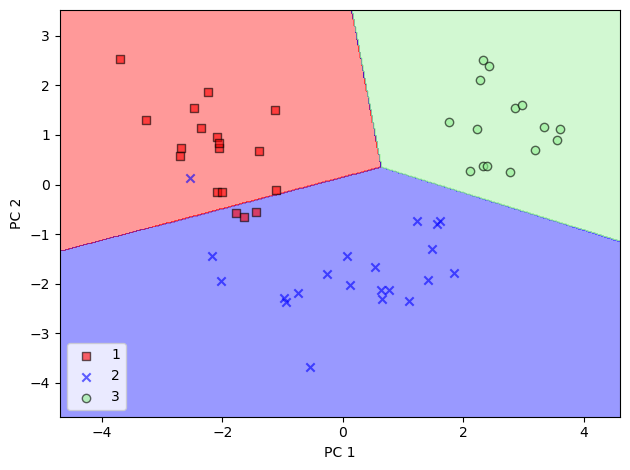

In [21]:
plot_decision_regions(X_test_pca, y_test, classifier=lr)
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='lower left')
plt.tight_layout()
# plt.savefig('images/05_05.png', dpi=300)
plt.show()

In [22]:
pca = PCA(n_components=None)
X_train_pca = pca.fit_transform(X_train_std)
pca.explained_variance_ratio_

array([0.36951469, 0.18434927, 0.11815159, 0.07334252, 0.06422108,
       0.05051724, 0.03954654, 0.02643918, 0.02389319, 0.01629614,
       0.01380021, 0.01172226, 0.00820609])

`n_components`에 (0, 1) 사이 실수를 입력하면 설명된 분산의 비율을 나타냅니다. 이 비율을 달성하기 위해 필요한 주성분 개수를 선택합니다.

In [23]:
pca = PCA(n_components=0.95)
pca.fit(X_train_std)
print('주성분 개수:', pca.n_components_)
print('설명된 분산 비율:', np.sum(pca.explained_variance_ratio_))

주성분 개수: 10
설명된 분산 비율: 0.966271440655874


`n_components='mle'`로 지정하면 토마스 민카(Thomas Minka)가 제안한 차원 선택 방식을 사용합니다(Minka, T. P. “Automatic choice of dimensionality for PCA”. In NIPS, pp. 598-604).

In [24]:
pca = PCA(n_components='mle')
pca.fit(X_train_std)
print('주성분 개수:', pca.n_components_)
print('설명된 분산 비율:', np.sum(pca.explained_variance_ratio_))

주성분 개수: 9
설명된 분산 비율: 0.949975302918623


`PCA`의 가장 큰 제약 사항 중 하나는 배치로만 실행되기 때문에 대용량 데이터셋을 처리하려면 많은 메모리가 필요합니다. `IncrementalPCA`를 사용하면 데이터셋의 일부를 사용하여 반복적으로 훈련할 수 있습니다.

`partial_fit()` 메서드는 네트워크나 로컬 파일 시스템으로부터 조금씩 데이터를 받아와 훈련할 수 있습니다. `fit()` 메서드는 `numpy.memmap`을 사용하여 로컬 파일로부터 데이터를 조금씩 읽어 올 수 있습니다. 한 번에 읽어 올 데이터 크기는 `IncrementalPCA` 클래스의 `batch_size`로 지정합니다. 기본값은 특성 개수의 5배입니다.

`IncrementalPCA`의 `n_components` 매개변수는 정수 값만 입력할 수 있습니다. 다음은 `partial_fit()` 메서드를 사용하여 앞의 `PCA`로 찾은 주성분의 결과와 비교하는 간단한 예입니다.

In [25]:
from sklearn.decomposition import IncrementalPCA

ipca = IncrementalPCA(n_components=9)
for batch in range(len(X_train_std)//25+1):
    X_batch = X_train_std[batch*25:(batch+1)*25]
    ipca.partial_fit(X_batch)

print('주성분 개수:', ipca.n_components_)
print('설명된 분산 비율:', np.sum(ipca.explained_variance_ratio_))

주성분 개수: 9
설명된 분산 비율: 0.9478392700446645


# 5.2 선형 판별 분석을 통한 지도방식의 데이터 압축

## 5.2.1 주성분 분석 vs 선형 판별 분석

In [26]:
Image(url='https://git.io/Jtsv8', width=400)

## 5.2.2 선형 판별 분석의 내부 동작 방식

1. 표준화 전처리
2. 클래스별 평균 벡터
3. 클래스 간 산포 행렬 $\boldsymbol S_B$, 클래스 내 산포 행렬 $\boldsymbol S_W$
4. $\boldsymbol S_W^{-1}\boldsymbol S_B$ 행렬의 고윳값
5. 고윳값을 내림차순 정렬
6. 고윳값이 가장 큰 k개의 고유 벡터 선택
7. 고유 벡터로 만든 변환 행렬로 데이터셋 투영

## 5.2.3 산포 행렬 계산

각 클래스에 대한 평균 벡터를 계산합니다:

In [27]:
np.set_printoptions(precision=4)

mean_vecs = []
for label in range(1, 4):
    mean_vecs.append(np.mean(X_train_std[y_train == label], axis=0))
    print('MV %s: %s\n' % (label, mean_vecs[label - 1]))

MV 1: [ 0.9066 -0.3497  0.3201 -0.7189  0.5056  0.8807  0.9589 -0.5516  0.5416
  0.2338  0.5897  0.6563  1.2075]

MV 2: [-0.8749 -0.2848 -0.3735  0.3157 -0.3848 -0.0433  0.0635 -0.0946  0.0703
 -0.8286  0.3144  0.3608 -0.7253]

MV 3: [ 0.1992  0.866   0.1682  0.4148 -0.0451 -1.0286 -1.2876  0.8287 -0.7795
  0.9649 -1.209  -1.3622 -0.4013]

